In [23]:
import pandas as pd
import kagglehub
from dataloader import load_dataset
from helper import extract_street_info
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Load the dataset
path = kagglehub.dataset_download("debayank2024/house-price-prediction")
df = load_dataset(path)

Loading dataset from: /home/mordicus/.cache/kagglehub/datasets/debayank2024/house-price-prediction/versions/1/modified_data.csv


In [25]:
df.head(5)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   str    
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   str    
 15  city            4600 non-null   str    
 16  statezip        4600 non-null   str    
 17  price_per_sqft  4600 non-null   float64
dtyp

The dataset does not have missing values.

In [27]:
df['date'] = pd.to_datetime(df['date'])

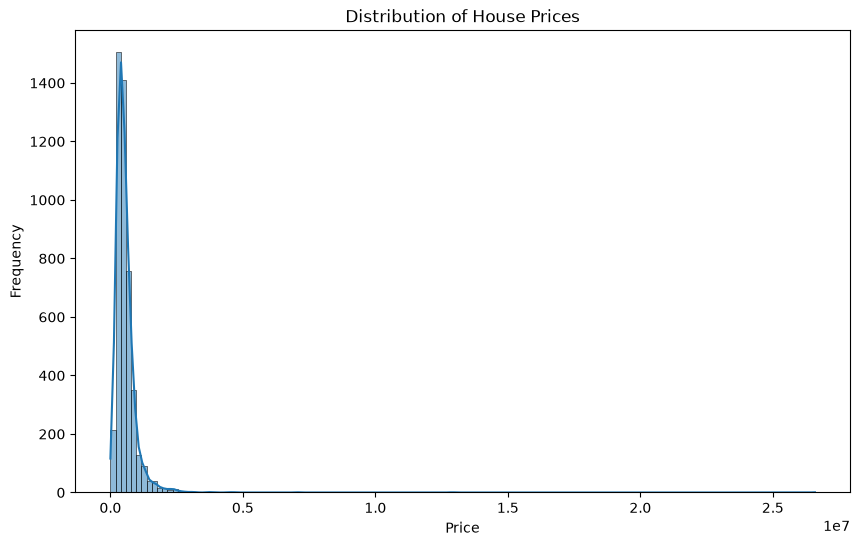

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

The distribution of prices is higly skewed to the right. This will require log-transformation.

In [29]:
for col in ['street', 'city', 'statezip']:
    print(f"{col} cardinality: {df[col].nunique()}")

street cardinality: 4525
city cardinality: 44
statezip cardinality: 77


street-column has high cardinality and is useless as such.

In [30]:
# Define common US street suffixes
# We use \b to ensure we match whole words and [A-Za-z] to capture the letters
suffixes = [
    'Ave', 'Avenue', 'St', 'Street', 'Blvd', 'Boulevard', 
    'Dr', 'Drive', 'Ln', 'Lane', 'Ct', 'Court', 'Way', 
    'Ter', 'Terrace', 'Cir', 'Circle', 'Pl', 'Place', 
    'Rd', 'Road', 'Parkway', 'Trace', 'Trail'
]

# Create a regex pattern: \b(Ave|Avenue|St|Street|...)\b
# We sort by length descending to ensure "Avenue" is matched before "Ave"
suffixes.sort(key=len, reverse=True)
pattern = r'\b(' + '|'.join(map(re.escape, suffixes)) + r')\b'


In [ ]:
# Apply the extraction
df[['street_name', 'street_type']] = df['street'].apply(
    lambda x: pd.Series(extract_street_info(pattern = pattern, street_name = x))
)

# Define the canonical mapping. This maps abbreviations to their full, standard names
suffix_mapping = {
    'Ave': 'Avenue',
    'Avenue': 'Avenue',
    'St': 'Street',
    'Street': 'Street',
    'Blvd': 'Boulevard',
    'Boulevard': 'Boulevard',
    'Dr': 'Drive',
    'Drive': 'Drive',
    'Ln': 'Lane',
    'Lane': 'Lane',
    'Ct': 'Court',
    'Court': 'Court',
    'Rd': 'Road',
    'Road': 'Road',
    'Pl': 'Place',
    'Place': 'Place',
    'Cir': 'Circle',
    'Circle': 'Circle',
    'Ter': 'Terrace',
    'Terrace': 'Terrace',
    'Way': 'Way',
    'Tr': 'Trace',
    'Trail': 'Trail'
}

#Normalize the extracted street_type
# This replaces the extracted value with the canonical name
df['street_type'] = df['street_type'].map(suffix_mapping).fillna(df['street_type'])

# Check the new distribution
print("Street Type Distribution:")
print(df['street_type'].value_counts())

# Show a few examples
print("\nSample of extracted data:")
print(df[['street', 'street_name', 'street_type']].head(10))

Street Type Distribution:
street_type
Avenue       1949
Street       1167
Place         806
Court         174
Way           155
Drive         123
Road           69
Lane           53
Other          37
Boulevard      32
Terrace        14
Trail          13
Circle          8
Name: count, dtype: int64

Sample of extracted data:
                     street           street_name street_type
0      18810 Densmore Ave N        18810 Densmore      Avenue
1           709 W Blaine St          709 W Blaine      Street
2  26206-26214 143rd Ave SE     26206-26214 143rd      Avenue
3           857 170th Pl NE             857 170th       Place
4         9105 170th Ave NE            9105 170th      Avenue
5            522 NE 88th St           522 NE 88th      Street
6         2616 174th Ave NE            2616 174th      Avenue
7         23762 SE 253rd Pl        23762 SE 253rd       Place
8   46611-46625 SE 129th St  46611-46625 SE 129th      Street
9          6811 55th Ave NE             6811 55th      